In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [16]:
#Hyperpameters
batch_size = 100
lr = 1e-4
epochs = 150
T = 1000
beta = torch.linspace(1e-4,0.02,T).to(device)
alpha = 1. -beta
alpha_hat = torch.cumprod(alpha,dim=0)

In [27]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.dim = dim
    def forward(self,time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = torch.exp(
            torch.arange(half_dim,device=device)*
            -(np.log(10000) / (half_dim - 1))
        )
        embeddings = time[:, None]*embeddings[None,:]
        embeddings = torch.cat((embeddings.sin(),embeddings.cos()),dim = -1)
        return embeddings


In [28]:
class Denoiser(nn.Module):
    def __init__(self):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(32),
            nn.Linear(32,64),
            nn.ReLU()
        )
        self.conv1 = nn.Conv2d(3,64,3,padding=1)
        self.conv2 = nn.Conv2d(64,64,3,padding=1)
        self.conv3 = nn.Conv2d(64,3,3,padding=1)

    # Note how 'def forward' lines up exactly under 'def __init__'
    def forward(self,x,t):
        t = self.time_mlp(t)
        t = t[:,:,None,None]
        x = self.conv1(x)
        x = x + t 
        x = F.relu(self.conv2(x))
        return self.conv3(x)

model = Denoiser().to(device)
optimizer = torch.optim.Adam(model.parameters(),lr=lr)


In [29]:
transform = transforms.Compose ([transforms.ToTensor(),transforms.Normalize((0.5,),(0.5,))])
dataset = torchvision.datasets.CIFAR10(
    root = './data',
    train = True,
    download = True,
    transform = transform
)
dataloader = DataLoader(dataset,batch_size = batch_size,shuffle = True)


In [30]:
def forward_diffusion(x0, t):
    noise = torch.randn_like(x0)
    
    # Corrected math here:
    sqrt_alpha_hat = torch.sqrt(alpha_hat[t])[:,None,None,None]
    sqrt_one_minus_alpha_hat = torch.sqrt(1 - alpha_hat[t])[:,None,None,None]
    
    return sqrt_alpha_hat * x0 + sqrt_one_minus_alpha_hat * noise, noise


In [31]:
for epoch in range(epochs):
    for images, _ in dataloader:
        # ADD THIS LINE: Move images to the GPU
        images = images.to(device)
        
        t = torch.randint(0, T, (images.size(0),), device=device)
        xt, noise = forward_diffusion(images, t)
        predicted_noise = model(xt, t.float())
        loss = F.mse_loss(predicted_noise, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")
print("Training completed!")


Epoch 1, Loss: 0.12028587609529495
Epoch 2, Loss: 0.0965256616473198
Epoch 3, Loss: 0.06224697083234787
Epoch 4, Loss: 0.07812857627868652
Epoch 5, Loss: 0.04920734092593193
Epoch 6, Loss: 0.04213474690914154
Epoch 7, Loss: 0.08682315051555634
Epoch 8, Loss: 0.04844077676534653
Epoch 9, Loss: 0.039033856242895126
Epoch 10, Loss: 0.04476328194141388
Epoch 11, Loss: 0.052188485860824585
Epoch 12, Loss: 0.05541018396615982
Epoch 13, Loss: 0.06924159079790115
Epoch 14, Loss: 0.04861285164952278
Epoch 15, Loss: 0.0465984046459198
Epoch 16, Loss: 0.05097564682364464
Epoch 17, Loss: 0.04873320832848549
Epoch 18, Loss: 0.049569569528102875
Epoch 19, Loss: 0.03318619355559349
Epoch 20, Loss: 0.038700688630342484
Epoch 21, Loss: 0.051205702126026154
Epoch 22, Loss: 0.04748624190688133
Epoch 23, Loss: 0.04727528244256973
Epoch 24, Loss: 0.051599085330963135
Epoch 25, Loss: 0.051656898111104965
Epoch 26, Loss: 0.05208268761634827
Epoch 27, Loss: 0.03737160563468933
Epoch 28, Loss: 0.04221220687031

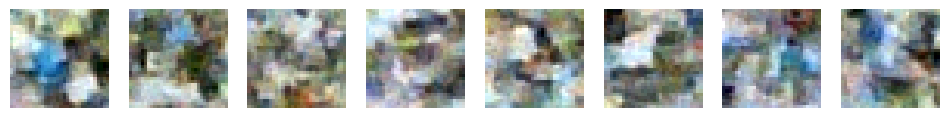

In [32]:
def sample(model,n):
    model.eval()
    x = torch.randn((n,3,32,32)).to(device)

    for t in reversed(range(T)):
        t_tensor = torch.full((n,),t,device = device)
        predicted_noise = model(x, t_tensor.float())
        alpha_t = alpha[t]
        alpha_hat_t = alpha_hat[t]
        beta_t = beta[t]

        if t>0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (1/torch.sqrt(alpha_t))*(x - (1-alpha_t)/torch.sqrt(1-alpha_hat_t)*predicted_noise)+torch.sqrt(beta_t)*noise
    return x

generated_images = sample(model,8)
generated_images = (generated_images + 1)/2
generated_images = generated_images.clamp(0,1).detach().cpu()
plt.figure(figsize = (12,4))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(generated_images[i].permute(1,2,0))
    plt.axis('off')
plt.show()        

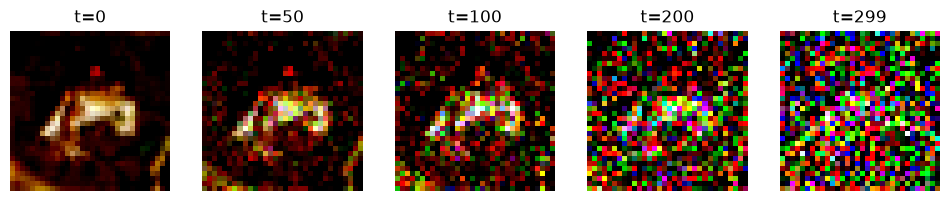

In [33]:
sample_img, _ = dataset[0]
sample_img = sample_img.unsqueeze(0).to(device)
plt.figure(figsize = (12,3))

for i,step in enumerate([0,50,100,200,299]):
    t = torch.tensor([step],device = device)
    xt, _ = forward_diffusion(sample_img,t)
    xt = xt.clamp(0,1).cpu()
    plt.subplot(1,5,i+1)
    plt.imshow(xt[0].permute(1,2,0))
    plt.title(f"t={step}")
    plt.axis('off')
plt.show()